# ¿Qué es la Visión Artificial?

La **visión artificial** es una tecnología que permite a las computadoras **capturar, procesar y analizar imágenes o videos** para identificar información y tomar decisiones de manera similar a como lo hace la visión humana.

Utiliza **cámaras, sensores, algoritmos e inteligencia artificial** para reconocer objetos, personas, patrones, colores, formas y otros elementos presentes en una imagen.

##  ¿Cómo funciona?

Generalmente, la visión artificial sigue estos pasos:

1.  **Captura:** obtiene una imagen o video mediante una cámara o sensor.
2.  **Procesamiento:** analiza y prepara la imagen para facilitar su interpretación.
3.  **Análisis:** utiliza algoritmos o modelos de inteligencia artificial para identificar elementos.
4.  **Resultado:** genera una respuesta o permite tomar una decisión según lo encontrado.

##  ¿Qué aplicaciones tiene?

La visión artificial tiene muchas aplicaciones en diferentes áreas:

-  **Vehículos autónomos:** detectan señales de tránsito, peatones y otros vehículos.
-  **Industria:** identifican productos defectuosos en una línea de producción.
-  **Medicina:** ayudan a analizar radiografías, tomografías y otras imágenes médicas.
-  **Reconocimiento facial:** permite identificar o verificar personas.
-  **Comercio:** facilita el reconocimiento y clasificación de productos.
-  **Seguridad:** permite detectar movimientos, objetos o personas mediante cámaras.
-  **Agricultura:** ayuda a detectar enfermedades en plantas y controlar cultivos.
-  **Robótica:** permite que los robots reconozcan objetos y se orienten en su entorno.
-  **Aplicaciones móviles:** se utiliza para reconocer textos, objetos, rostros y códigos QR.

##  Ejemplos de aplicaciones y herramientas

Algunas aplicaciones y tecnologías que utilizan visión artificial son:

- **Google Lens:** reconoce objetos, textos, lugares y productos mediante la cámara.
- **Face ID:** utiliza reconocimiento facial para identificar al usuario.
- **Google Photos:** reconoce y organiza personas, lugares y objetos en fotografías.
- **Snapchat:** utiliza visión artificial para aplicar filtros y efectos sobre rostros.
- **Tesla Autopilot:** utiliza cámaras y sistemas de visión para interpretar el entorno del vehículo.
- **OCR:** permite convertir imágenes de texto en texto digital.

> **En resumen:** la visión artificial permite que las máquinas **"vean" e interpreten información visual** utilizando cámaras, procesamiento de imágenes e inteligencia artificial.


### Detección de Rostros con Python
La detección de rostros es una técnica de visión artificial que permite identificar automáticamente los rostros de las personas dentro de una imagen o video. Su objetivo es encontrar dónde se encuentran las caras y marcar su posición, por ejemplo, dibujando un rectángulo alrededor de cada rostro. Se utiliza en cámaras de seguridad, aplicaciones de fotografía, sistemas de acceso y otras aplicaciones de inteligencia artificial.

## ¿Cómo funciona en Python?

En Python, esto se puede hacer utilizando la biblioteca OpenCV. Primero se carga un modelo especializado en detectar rostros, después se lee la imagen y se convierte a escala de grises para facilitar el procesamiento. Luego, OpenCV analiza la imagen y busca patrones que correspondan a un rostro. Cuando encuentra uno, devuelve su posición y tamaño, y Python utiliza esos datos para dibujar un rectángulo alrededor de la cara.


In [1]:
# 1. Instalación de OpenCV Library

%pip install opencv-contrib-python==4.10.0.84

Note: you may need to restart the kernel to use updated packages.


In [2]:
# 2. Importación de la librería

import cv2
import os

print("Versión:", cv2.__version__)
print("CascadeClassifier:", hasattr(cv2, "CascadeClassifier"))

# 2.1 Comprobar que la imagen existe

print(os.path.exists('rostros.jpe'))

# 3. Cargar la imagen

imgpath = 'rostros.jpe'

# 4. Leer la imagen

img = cv2.imread(imgpath)

# 5. Mostrar las dimensiones

print(img.shape)

Versión: 4.10.0
CascadeClassifier: True
True
(316, 474, 3)


In [6]:
# 6. Convertir la imagen a escala de grises

gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

gray_img.shape

(316, 474)

In [5]:
# 3. Cargar el clasificador

cascade = "haarcascade_frontalface_default.xml"

face_cascade = cv2.CascadeClassifier(cascade)

# Verificar si el clasificador se cargó correctamente

if face_cascade.empty():
    print("Error: No se pudo cargar, verificar el XML")
else:
    print("Clasificador en cascada cargado correctamente")

Clasificador en cascada cargado correctamente


In [7]:
# 9. Detectar rostros en la imagen en escala de grises
# Se utiliza la función detectMultiScale() para detectar
# rostros de diferentes tamaños en la imagen.

face = face_cascade.detectMultiScale(
    gray_img,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(40, 40)
)

In [8]:
# 10.For para recorrer todas las caras y dibujar un rectangulo
#sobre la imagen original(img)

for (x, y, w, h) in face:
    cv2.rectangle(img, (x,y),(x+w , y+h), (255, 200, 000), 2)

# 11. Las imagenes e cragn en BGR , se debe concvetir a RGB
img_rgb=cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

(np.float64(-0.5), np.float64(473.5), np.float64(315.5), np.float64(-0.5))

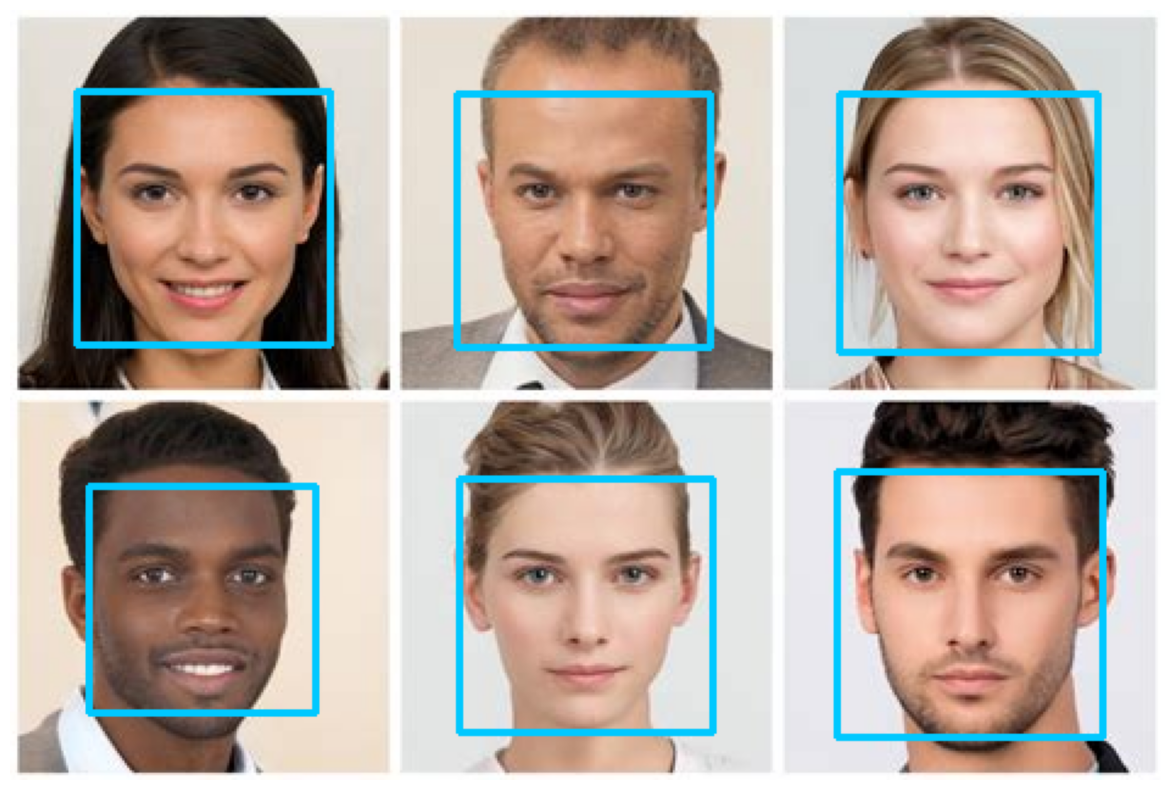

In [9]:
# 12. Importar Matplotlib para mostrar la imagen

import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))

plt.imshow(img_rgb)

plt.axis('off')

## Captura de video en tiempo real

In [19]:
# 1. Acceder a la cámara de nuestro pc y leer un flujo de datos en tiempo real.
video_capture =cv2.VideoCapture(0)

# Función para detectar rostros con flujo de video y dibujar un recuadro delimitador
def detect_bounding_box(vid):
    gray_img = cv2.cvtColor(vid, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray_img, 1.1 , 10 , minSize=(40,40))
    for (x, y, w, h) in faces:
        cv2.rectangle(vid, (x,y),(x+w , y+h), (255, 200, 000), 2)
    return faces 


In [20]:
# 3. Bucle para detectar caras en Real Time,
# capturar fotograma y aplicar detección de rostros

while True:

    result, video_frame = video_capture.read()

    if result is False:
        break

    faces = detect_bounding_box(video_frame)

    cv2.imshow("Mi cara detectada", video_frame)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

video_capture.release()
cv2.destroyAllWindows()